# ESG Screening and RAG: Implemented Classifier vs Interface Contract

**Docker image**: `ml4t-gpu`

**Book Reference**: Chapter 22, Section 22.8 (Applications and Strategic Choices)

This notebook compares two approaches to ESG (Environmental, Social, Governance)
analysis:

1. **Implemented screening**: keyword ESG categories plus pretrained FinBERT sentiment
2. **RAG interface contract**: evidence requirements for qualitative due diligence

**Learning Objectives**:
- Contrast fixed-taxonomy classification with cited narrative analysis.
- Map ESG workflows to the architecture that fits their output requirements.
- Use latency, flexibility, and verifiability as selection criteria.

**Prerequisites**: Bloomberg financial news dataset
(`data/alternative/news/bloomberg/`). No RAG answers are generated in this notebook.

## Key Insight
The choice isn't about which technology is "better" - it's about which is
appropriate for the task at hand.

## 1. Setup and Imports

The setup fixes the headline and question budgets so the comparison isolates
architectural trade-offs instead of dataset-size or runtime noise.

In [1]:
"""ESG Analysis: RAG vs Fine-Tuning - Comparing classification and retrieval approaches."""

import hashlib
import json
import time
import warnings

warnings.filterwarnings("ignore")

import plotly.graph_objects as go

# Core imports
import polars as pl
import torch
from plotly.subplots import make_subplots
from transformers import AutoModelForSequenceClassification, AutoTokenizer, pipeline
from transformers.utils import logging as transformers_logging

# ML4T configuration
from data import load_bloomberg_news
from utils.reproducibility import set_global_seeds
from utils.style import COLORS

transformers_logging.set_verbosity_error()

In [2]:
MAX_HEADLINES = 0
MAX_QUESTIONS = 0
SEED = 42
REQUIRE_GPU = True
FINBERT_MODEL = "ProsusAI/finbert"
FINBERT_REVISION = "4556d13015211d73dccd3fdd39d39232506f3e43"

In [3]:
set_global_seeds(SEED)
if REQUIRE_GPU and not torch.cuda.is_available():
    raise RuntimeError("FinBERT inference requires the ml4t-gpu service with CUDA.")
INFERENCE_DEVICE = 0 if torch.cuda.is_available() else -1
print(f"FinBERT device: {'cuda:0' if INFERENCE_DEVICE == 0 else 'cpu'}")

FinBERT device: cuda:0


## Approach A: Implemented ESG Screening

The implemented path combines a keyword taxonomy with pretrained FinBERT
sentiment. It does not fine-tune an ESG classifier in this notebook.

**Strengths**: Scalable, fast, produces numeric time series
**Limitations**: Fixed taxonomy, no explanations

**Interpretation**: The output path and budget settings frame this notebook as
a workflow comparison. The result matters less as a benchmark than as a guide
to which architecture fits a research team's operating model.

In [4]:
print("Transformers available")

Transformers available


**Interpretation**: The transformer availability check is a practical branch
in the experiment. Production fails closed if the pinned classifier is not
available, so later outputs cannot silently describe a substituted model.


In [5]:
# Load real financial news headlines from the Bloomberg archive
news_df = load_bloomberg_news()
required_columns = {"timestamp", "headline"}
missing_columns = required_columns - set(news_df.columns)
if missing_columns:
    raise ValueError(f"Bloomberg news loader violates canonical schema: missing {missing_columns}.")

# Filter for ESG-related headlines using keyword matching
esg_keywords = r"(?i)(climate|carbon|emission|sustain|ESG|renewable|diversity|governance|environmental|green.bond|pollution|social.responsibility|net.zero|solar|wind.energy|deforestation|water.scarcity|labor.rights|board.independence|executive.compensation)"
esg_news = (
    news_df.filter(pl.col("headline").str.contains(esg_keywords))
    .filter(pl.col("headline").str.len_chars() > 30)
    .sort(["timestamp", "headline"], descending=[True, False])
)
print(f"ESG-relevant headlines in Bloomberg corpus: {len(esg_news):,}")

# Sample a diverse set across E, S, G categories
N_HEADLINES = MAX_HEADLINES if MAX_HEADLINES > 0 else 20
selected_headlines = esg_news.sample(N_HEADLINES, seed=SEED).sort(
    ["timestamp", "headline"], descending=[True, False]
)
ESG_HEADLINES = selected_headlines["headline"].to_list()
selection_sha256 = hashlib.sha256(
    "\n".join(
        f"{row['timestamp'].isoformat()}|{row['headline']}"
        for row in selected_headlines.iter_rows(named=True)
    ).encode()
).hexdigest()
print(f"Sampled {len(ESG_HEADLINES)} headlines for classification")
print(f"Selected-row SHA-256: {selection_sha256}")

ESG-relevant headlines in Bloomberg corpus: 7,293
Sampled 20 headlines for classification
Selected-row SHA-256: 4744051d9056d29ace1b5259c679406818f6e4652de88f6bc6060e670cb3211b


### Keyword-based ESG categorization

Simple rule-based classifier that assigns E, S, or G labels using
keyword matching. Used as a proxy when a fine-tuned ESG taxonomy
model is not available.

In [6]:
def categorize_esg(text: str) -> str:
    """Simple keyword-based ESG categorization."""
    text_lower = text.lower()
    if any(
        kw in text_lower
        for kw in ["carbon", "emission", "environmental", "solar", "sustainability", "net-zero"]
    ):
        return "Environmental"
    elif any(
        kw in text_lower
        for kw in ["worker", "safety", "labor", "diversity", "data breach", "customer"]
    ):
        return "Social"
    elif any(
        kw in text_lower for kw in ["board", "ceo", "compensation", "shareholder", "governance"]
    ):
        return "Governance"
    else:
        return "Other"

### Sentiment-based headline classification

Uses FinBERT as a sentiment proxy. In production, a dedicated ESG
classifier (e.g., FinBERT-ESG) would replace this with a fine-grained
taxonomy output.

### Load the sentiment classifier

Production requires the pinned FinBERT snapshot. A missing dependency fails
closed instead of silently changing the model behind the reported results.


In [7]:
def load_finbert_pipeline():
    """Return the pinned FinBERT sentiment pipeline."""
    tokenizer = AutoTokenizer.from_pretrained(
        FINBERT_MODEL,
        revision=FINBERT_REVISION,
        local_files_only=True,
    )
    model = AutoModelForSequenceClassification.from_pretrained(
        FINBERT_MODEL,
        revision=FINBERT_REVISION,
        local_files_only=True,
    )
    classifier = pipeline(
        "sentiment-analysis",
        model=model,
        tokenizer=tokenizer,
        device=INFERENCE_DEVICE,
    )
    return classifier, FINBERT_MODEL

### Classify the ESG headlines

Apply the sentiment model, add a coarse E/S/G label, and record latency so the
architecture comparison includes both output type and throughput.

**Interpretation**: The model-loading branch determines whether we are testing
a finance-tuned sentiment backbone or a generic fallback. That result shapes
how much weight to put on the classification outputs below.


In [8]:
def classify_esg_headlines(headlines: list) -> pl.DataFrame:
    """Classify ESG headlines using FinBERT sentiment as proxy."""
    print("Classifying headlines with sentiment model...")
    start_time = time.time()
    classifier, model_used = load_finbert_pipeline()
    print(f"Sentiment model in use: {model_used}")
    parameter_device = next(classifier.model.parameters()).device
    if REQUIRE_GPU and parameter_device.type != "cuda":
        raise RuntimeError(f"FinBERT parameters are on {parameter_device}, not CUDA.")
    print(f"FinBERT parameters: {parameter_device}")

    results = []
    for headline in headlines:
        result = classifier(headline[:512])[0]  # Truncate to model max
        results.append(
            {
                "headline": headline,
                "model": model_used,
                "category": categorize_esg(headline),
                "sentiment": result["label"],
                "confidence": result["score"],
            }
        )

    elapsed = time.time() - start_time
    print(f"Classified {len(headlines)} headlines in {elapsed:.2f}s")
    print(f"Throughput: {len(headlines) / elapsed:.1f} docs/sec")

    return pl.DataFrame(results).with_columns(
        pl.lit(1_000 * elapsed / max(len(headlines), 1)).alias("latency_ms_per_headline")
    )

**Interpretation**: The classification helper turns ESG inputs into compact
numeric outputs suitable for screening and backtests. That is the structural
advantage classification keeps over more flexible RAG systems.


In [9]:
# Run classification
print("=== Approach A: Pretrained FinBERT Inference ===\n")

classification_results = classify_esg_headlines(ESG_HEADLINES)
print("\nClassification Results:")
classification_results

=== Approach A: Pretrained FinBERT Inference ===

Classifying headlines with sentiment model...


Sentiment model in use: ProsusAI/finbert
FinBERT parameters: cuda:0
Classified 20 headlines in 0.72s
Throughput: 27.6 docs/sec

Classification Results:


headline,model,category,sentiment,confidence,latency_ms_per_headline
str,str,str,str,f64,f64
"""Mexico’s Calderon Leads Probe …","""ProsusAI/finbert""","""Other""","""neutral""",0.899589,36.16761
"""Obama Climate Plan No War on C…","""ProsusAI/finbert""","""Other""","""neutral""",0.908166,36.16761
"""Mongolia Opens $122 Million Wi…","""ProsusAI/finbert""","""Other""","""positive""",0.56712,36.16761
"""China’s Chaori Solar Warns of …","""ProsusAI/finbert""","""Environmental""","""negative""",0.919578,36.16761
"""German Renewables Groups Propo…","""ProsusAI/finbert""","""Other""","""neutral""",0.824095,36.16761
…,…,…,…,…,…
"""Belectric Wins Contract for La…","""ProsusAI/finbert""","""Environmental""","""positive""",0.914647,36.16761
"""Australia Should Price Carbon …","""ProsusAI/finbert""","""Environmental""","""neutral""",0.828552,36.16761
"""Czech Carbon Registry Aims to …","""ProsusAI/finbert""","""Environmental""","""neutral""",0.827666,36.16761


**Interpretation**: The classification path yields compact, portfolio-ready
outputs. That makes it ideal for screening large universes, but the result is
still a label rather than an explanation tied to source evidence.

## Approach B: RAG Interface Contract

A RAG implementation must answer open-ended questions with retrieved evidence,
citations, and explicit abstention. This notebook records that contract without
inventing answers, citations, confidence, or latency.

In [10]:
# Sample ESG questions for RAG
ESG_QUESTIONS = [
    "Summarize the company's strategy for reducing Scope 2 emissions and list any stated targets.",
    "What key performance indicators does the company use to track progress on sustainability?",
    "Identify governance concerns related to executive compensation or board independence.",
]

if MAX_QUESTIONS > 0:
    ESG_QUESTIONS = ESG_QUESTIONS[:MAX_QUESTIONS]

### Declare the evidence contract

Each question defines the evidence a live assistant must return before its
output can enter a comparison.

In [11]:
def build_rag_contract(questions: list[str]) -> pl.DataFrame:
    """Return validation fields required from a future live RAG run."""
    return pl.DataFrame(
        {
            "question": questions,
            "required_output": ["grounded narrative"] * len(questions),
            "required_evidence": ["source id + quoted span"] * len(questions),
            "required_checks": ["citation support + abstention"] * len(questions),
            "measured_here": [False] * len(questions),
        }
    )

**Interpretation**: This is a specification, not a RAG result. Notebook 05
implements retrieval; a live generation run would still need citation and
abstention evaluation before the approaches could be compared empirically.


In [12]:
# Run RAG analysis
print("\n=== Approach B: RAG Interface Contract ===\n")

rag_contract = build_rag_contract(ESG_QUESTIONS)
print("\nRequired RAG evidence:")
rag_contract


=== Approach B: RAG Interface Contract ===


Required RAG evidence:


question,required_output,required_evidence,required_checks,measured_here
str,str,str,str,bool
"""Summarize the company's strate…","""grounded narrative""","""source id + quoted span""","""citation support + abstention""",false
"""What key performance indicator…","""grounded narrative""","""source id + quoted span""","""citation support + abstention""",false
"""Identify governance concerns r…","""grounded narrative""","""source id + quoted span""","""citation support + abstention""",false


**Interpretation**: No answers or latency are reported because this notebook
does not execute a RAG producer. That boundary prevents interface requirements
from being mistaken for measured performance.

## Comparison: Classification vs RAG

This table separates the implemented screen from requirements that a future
RAG producer must satisfy.

In [13]:
# Build comparison table
comparison = pl.DataFrame(
    {
        "Dimension": [
            "Primary Output",
            "Scalability",
            "Flexibility",
            "Verifiability",
            "Knowledge Updates",
            "Latency",
            "Best Use Case",
        ],
        "Implemented Screening": [
            "Keyword category + sentiment label",
            "High (batch processing)",
            "Low (fixed taxonomy)",
            "Indirect (confidence)",
            "Update rules or replace model",
            "Measured here (classification throughput)",
            "Systematic factor construction",
        ],
        "RAG Contract": [
            "Requires narrative + citations",
            "Not measured here",
            "Open-ended by design",
            "Requires cited source spans",
            "Requires corpus provenance",
            "Not measured here",
            "Due-diligence interface specification",
        ],
    }
)

print("\n=== Approach Comparison ===\n")
comparison


=== Approach Comparison ===



Dimension,Implemented Screening,RAG Contract
str,str,str
"""Primary Output""","""Keyword category + sentiment l…","""Requires narrative + citations"""
"""Scalability""","""High (batch processing)""","""Not measured here"""
"""Flexibility""","""Low (fixed taxonomy)""","""Open-ended by design"""
"""Verifiability""","""Indirect (confidence)""","""Requires cited source spans"""
"""Knowledge Updates""","""Update rules or replace model""","""Requires corpus provenance"""
"""Latency""","""Measured here (classification …","""Not measured here"""
"""Best Use Case""","""Systematic factor construction""","""Due-diligence interface specif…"


**Interpretation**: The comparison highlights a fundamental architectural
trade-off. The screening path produces fixed-schema outputs and measured
throughput. RAG quality and latency are not measured here, so the notebook
makes no empirical performance comparison between them.

## Decision Framework

Use this framework to select the appropriate approach:

| Question | Choose Classification | Choose RAG |
|----------|----------------------|------------|
| Need to process 1000s of documents? | **Yes** | No |
| Need numeric time series? | **Yes** | No |
| Need to explain the reasoning? | No | **Yes** |
| Need to ask follow-up questions? | No | **Yes** |
| Need real-time processing? | **Yes** | Maybe |
| Knowledge changes frequently? | No | **Yes** |

In [14]:
# Performance comparison
print("\n=== Performance Statistics ===\n")

# Classification stats
if classification_results.height > 0:
    print("Classification Approach:")
    print(f"  Headlines processed: {classification_results.height}")
    print(f"  Unique categories: {classification_results['category'].n_unique()}")
    avg_confidence = classification_results["confidence"].mean()
    if avg_confidence is not None:
        print(f"  Average confidence: {avg_confidence:.2%}")

# RAG contract status
print("\nRAG Contract:")
print(f"  Questions specified: {rag_contract.height}")
print("  Answers generated: 0")
print("  Latency measured: No")


=== Performance Statistics ===

Classification Approach:
  Headlines processed: 20
  Unique categories: 2
  Average confidence: 79.64%

RAG Contract:
  Questions specified: 3
  Answers generated: 0
  Latency measured: No


**Interpretation**: The classifier provides a measured screening path. The RAG
side remains a validation contract until a cited producer is executed.

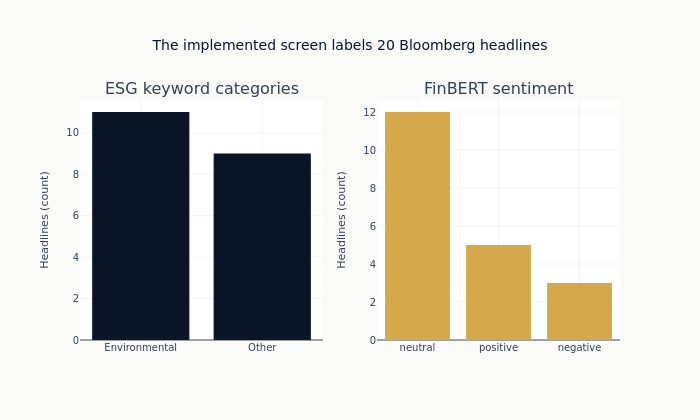

In [15]:
category_counts = classification_results.group_by("category").len().sort("len", descending=True)
sentiment_counts = classification_results.group_by("sentiment").len().sort("len", descending=True)

fig = make_subplots(rows=1, cols=2, subplot_titles=("ESG keyword categories", "FinBERT sentiment"))
fig.add_trace(
    go.Bar(
        x=category_counts["category"],
        y=category_counts["len"],
        marker_color=COLORS["blue"],
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Bar(
        x=sentiment_counts["sentiment"],
        y=sentiment_counts["len"],
        marker_color=COLORS["amber"],
    ),
    row=1,
    col=2,
)
fig.update_layout(
    title=f"The implemented screen labels {classification_results.height} Bloomberg headlines",
    height=420,
    showlegend=False,
)
fig.update_yaxes(title_text="Headlines (count)")
fig.show()

In [16]:
print("\n=== ESG Analysis Comparison Summary ===")
print(f"Classification: {classification_results.height} headlines -> numeric scores")
print(f"RAG: {rag_contract.height} question contracts -> no generated answers")
print("\nBoundary: execute and evaluate a cited RAG producer before comparing performance")


=== ESG Analysis Comparison Summary ===
Classification: 20 headlines -> numeric scores
RAG: 3 question contracts -> no generated answers

Boundary: execute and evaluate a cited RAG producer before comparing performance


In [17]:
completion_record = {
    "selected_rows_sha256": selection_sha256,
    "headlines": classification_results.height,
    "rag_questions": rag_contract.height,
    "models": classification_results["model"].unique().sort().to_list(),
    "model_revision": FINBERT_REVISION,
    "device": "cuda" if INFERENCE_DEVICE == 0 else "cpu",
    "category_counts": category_counts.to_dicts(),
    "sentiment_counts": sentiment_counts.to_dicts(),
}
print(f"COMPLETION_RECORD={json.dumps(completion_record, sort_keys=True)}")

COMPLETION_RECORD={"category_counts": [{"category": "Environmental", "len": 11}, {"category": "Other", "len": 9}], "device": "cuda", "headlines": 20, "model_revision": "4556d13015211d73dccd3fdd39d39232506f3e43", "models": ["ProsusAI/finbert"], "rag_questions": 3, "selected_rows_sha256": "4744051d9056d29ace1b5259c679406818f6e4652de88f6bc6060e670cb3211b", "sentiment_counts": [{"len": 12, "sentiment": "neutral"}, {"len": 5, "sentiment": "positive"}, {"len": 3, "sentiment": "negative"}]}


## Key Takeaways

**Interpretation**: The final recommendation is architectural, not
ideological. The result suggests using classification for breadth and RAG for
depth when the workflow needs explanations tied to source evidence.

1. **The choice depends on the output contract**: Screening produces compact
   labels, while due diligence requires supported narrative evidence.

2. **Classification produces portfolio-ready outputs**: Numeric scores
   and labels feed directly into factor models and systematic strategies
   (see Chapter 10 for text feature engineering).

3. **RAG is not audit-ready by definition**: A candidate must prove that every
   claim is supported by a cited source span and that unsupported questions
   trigger abstention.

4. **Many firms use both**: Classification identifies *which* companies
   warrant attention; RAG enables *understanding* what they are doing.
   The two approaches are complementary, not competing.

5. **Measure before comparing**: Classification throughput is measured here;
   RAG latency and answer quality are deliberately left unreported.

**Next**: `07_institutional_holdings_graph` extends the RAG approach
with graph-structured features from 13F filings.

**Book reference**: Section 22.8 discusses when to use RAG vs.
fine-tuning, including the decision framework shown above.